Провести парсинг сайта `https://auto.drom.ru/` и создать список с автомобилями из области спец. размещения. Реализовать список словарей, где каждый словарь будет хранить ссылку на автомобиль, его марку и модель, цену.

Область спец. размещения представлена ниже (выделена жёлтым)

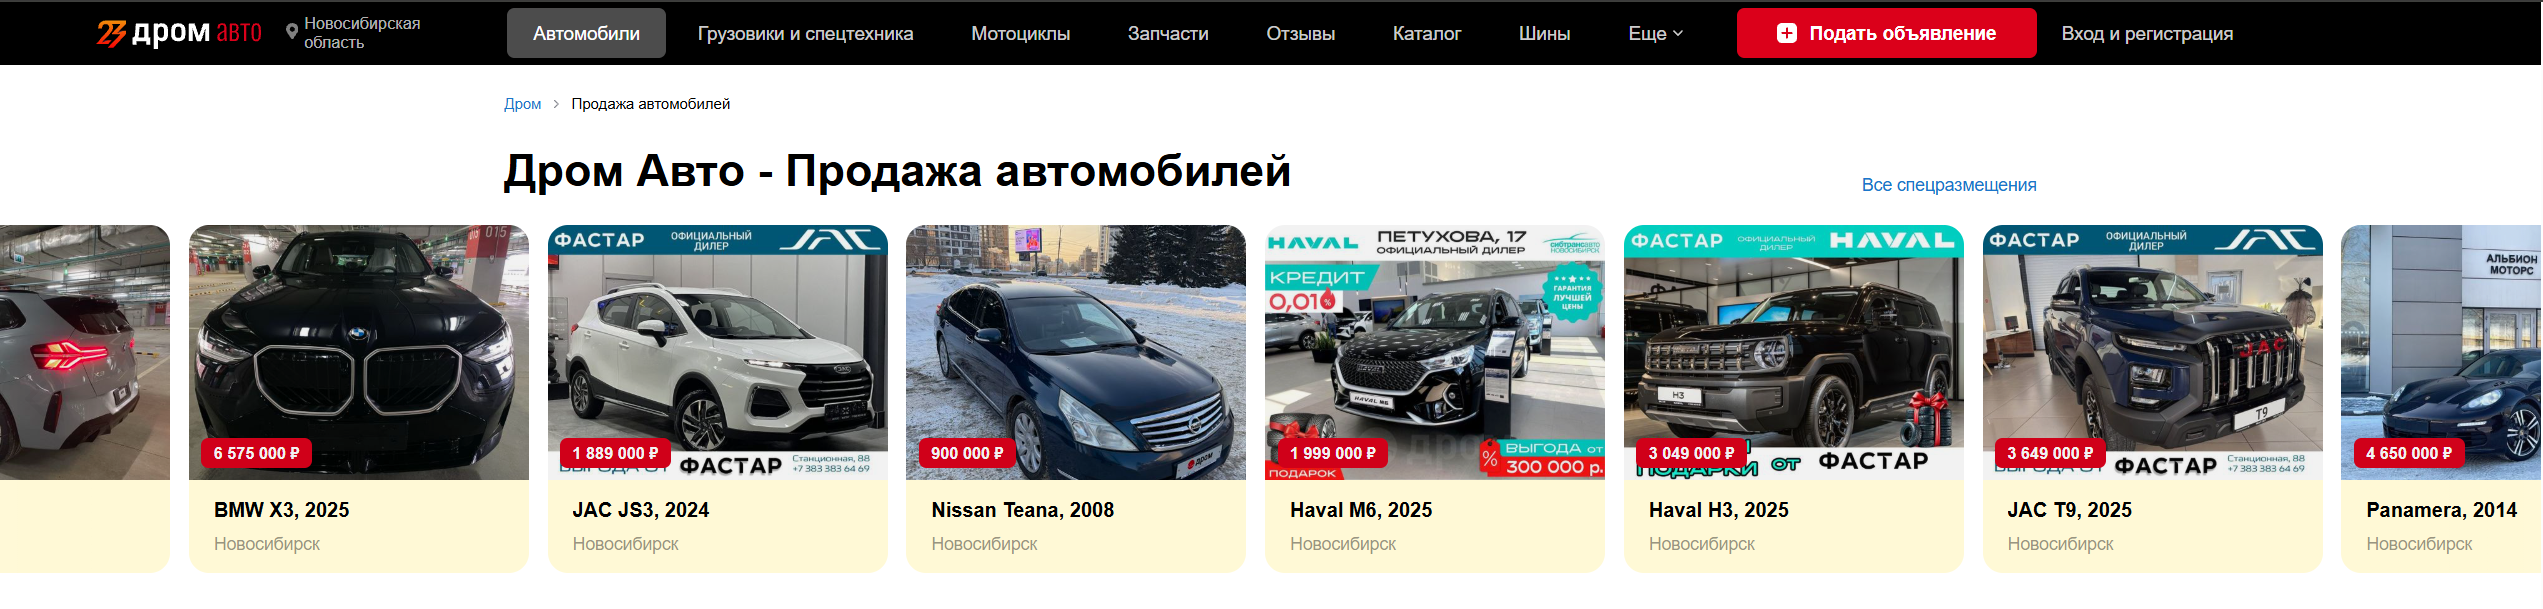

Если хочется попрактиковаться, то можно спарсить и другие страницы, например страницу с объявлениями по конкретной марке или модели.

In [101]:
import requests
from bs4 import BeautifulSoup

In [104]:
site = "https://auto.drom.ru/region36/premium/"
response = requests.get(site)
if response.status_code == 200:
  soup = BeautifulSoup(response.text, "html.parser")
  cars = soup.find_all("a", class_ = "css-b5o66h e18mkgj90")
  print(len(cars))

  car_list =[]
  for car in cars:
    link = car.get("href")
    model = car.find("span", class_ = "css-1t71ine e16zdi0i0").text
    price = car.find("div", class_ = "css-luilqb egua2dj0").text.replace(" ₽", "").replace("\xa0", "")
    item = {"Ссылка": link, "Модель": model, "Цена": int(price)}
    car_list.append(item)
print(car_list)

7
[{'Ссылка': 'https://auto.drom.ru/voronezh/mitsubishi/pajero/820943371.html', 'Модель': 'Mitsubishi Pajero 2007', 'Цена': 1150000}, {'Ссылка': 'https://auto.drom.ru/rossosh/volkswagen/tiguan/883090160.html', 'Модель': 'Volkswagen Tiguan 2021', 'Цена': 3800000}, {'Ссылка': 'https://auto.drom.ru/voronezh/tesla/model_3/809260800.html', 'Модель': 'Tesla Model 3 2022', 'Цена': 3900000}, {'Ссылка': 'https://auto.drom.ru/povorino/lada/priora/616615928.html', 'Модель': 'Лада Приора 2012', 'Цена': 500000}, {'Ссылка': 'https://auto.drom.ru/voronezh/chevrolet/tahoe/448731325.html', 'Модель': 'Chevrolet Tahoe 2013', 'Цена': 2950000}, {'Ссылка': 'https://auto.drom.ru/voronezh/ac/cobra/179895404.html', 'Модель': 'AC Cobra 2023', 'Цена': 15000000}, {'Ссылка': 'https://auto.drom.ru/voronezh/mercedes-benz/w123/307091879.html', 'Модель': 'Mercedes-Benz W123 1982', 'Цена': 229999}]
